# **Sistema de Suporte à Decisão (SSD) — Dimensionamento e Expansão de Infraestrutura em Nuvem (Versão 2.0)**

**Disciplina:** Sistemas de Suporte à Decisão - UnB  

**Objetivo:** MVP para Avaliação de Viabilidade e Expansão de Capacidade Operacional de Data Center

## **Base de Dados**

O dataset utilizado neste projeto foi extraído do Kaggle:

* **Dataset:** Hyperscale Data Center Dataset (https://www.kaggle.com/datasets/deeplumiere/hyperscale-data-center-dataset)
* **Autor:** DeepLumiere
* **Arquivos consumidos:** green_ai_datacenter.csv

## **Fase 1: Perguntar (Compreensão do Problema de Negócio)**

Empresas de computação em nuvem lidam com um volume crescente de dados. O grande desafio gerencial é saber o momento exato de investir na expansão física dos seus data centers.

Investir cedo demais (comprar novos servidores) gera custos desnecessários com capacidade ociosa e manutenção. Por outro lado, demorar muito para expandir faz com que os servidores atuais fiquem sobrecarregados, superaquecidos e percam eficiência.

**A Pergunta Central de Negócio:**
A empresa deve aprovar o investimento imediato para construir uma nova unidade ou deve postergar essa expansão e otimizar a infraestrutura que já possui?

**Critérios de Decisão:**
* **Custo:** O envelhecimento e o alto consumo de energia dos servidores justificam a troca?
* **Risco:** Qual é a taxa de servidores que já operam no limite de armazenamento e sob estresse térmico?
* **Prazo:** A folga de capacidade atual é suficiente para cobrir os 6 meses necessários para construir uma nova unidade?

## **Fase 2: Preparar (Coleta e Configuração dos Dados)**

Nesta etapa, preparamos o ambiente de trabalho e importamos a base de dados de telemetria operacional diretamente do Kaggle, garantindo que o processo seja automatizado e reprodutível. A base contém informações vitais sobre uso de armazenamento, consumo energético e temperatura de milhares de servidores.

In [1]:
# Importação das bibliotecas essenciais
import pandas as pd      # Usada para manipular e ler a tabela de dados
import numpy as np       # Usada para cálculos numéricos rápidos
import os                # Usada para interagir com o sistema de arquivos
from google.colab import files # Usada para fazer o upload da credencial do Kaggle

print("Por favor, faça o upload do arquivo 'kaggle.json' que você baixou:")
files.upload() # Abre a janela para você selecionar o kaggle.json do seu computador

# Configuração da credencial de segurança do Kaggle no ambiente do Colab
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download direto da base de dados usando a API oficial
print("\nBaixando a base de dados do Kaggle...")
!kaggle datasets download -d deeplumiere/hyperscale-data-center-dataset

# Extração (descompactação) do arquivo baixado
!unzip -q hyperscale-data-center-dataset.zip -d dataset_extracao/

# Carregamento da tabela completa para a memória do Python (DataFrame)
caminho_arquivo = 'dataset_extracao/green_ai_datacenter.csv'
df_bruto = pd.read_csv(caminho_arquivo)

# Exibe a quantidade de linhas e colunas para confirmar o sucesso da operação
total_linhas, total_colunas = df_bruto.shape
print(f"\nSucesso! A base original possui {total_linhas} linhas e {total_colunas} colunas.")

Por favor, faça o upload do arquivo 'kaggle.json' que você baixou:


Saving kaggle.json to kaggle.json

Baixando a base de dados do Kaggle...
Dataset URL: https://www.kaggle.com/datasets/deeplumiere/hyperscale-data-center-dataset
License(s): MIT
100% 7.46M/7.46M [00:00<00:00, 54.4MB/s]


Sucesso! A base original possui 100000 linhas e 35 colunas.


## **Fase 3: Processar (Auditoria de Integridade e Limpeza de Dados)**

Antes de realizar qualquer transformação, é fundamental auditar a qualidade da base de dados. Um modelo de decisão construído sobre dados defeituosos gerará recomendações incorretas (o princípio do *Garbage In, Garbage Out*).

Nesta fase, avaliamos e tratamos os dados sob cinco dimensões de integridade:

1. **Relevância:** A base bruta possui 35 colunas. Descartamos o ruído e selecionamos apenas as 8 variáveis que impactam diretamente a tríade de decisão (Custo, Risco e Prazo).
2. **Completude:** Checagem de valores ausentes ou corrompidos (*Nulos/NaN*) que possam quebrar fórmulas matemáticas.
3. **Consistência:** Verificação de registros duplicados que podem inflar artificialmente a contagem de servidores lotados ou os custos operacionais.
4. **Viés (Bias):** Identificação de subgrupos que distorcem a realidade da operação. Sabemos que servidores com 10 e 11 anos são obsoletos, operam quase sem carga e distorcem a relação real entre energia e custo. Eles precisam ser filtrados da análise principal.
5. **Correção/Precisão:** Validação dos limites estatísticos para garantir que não existem valores impossíveis (como temperaturas negativas ou ocupação de armazenamento acima de 100%).

In [2]:
# ==============================================================================
# PASSO 1: RELEVÂNCIA (Isolamento das variáveis de negócio)
# ==============================================================================
colunas_relevantes = [
    "server_age_years",      # Idade do servidor (anos)
    "workload_intensity",    # Demanda de processamento
    "storage_utilization",   # Ocupação do armazenamento (%)
    "power_consumption_kw",  # Consumo de energia (kW)
    "compute_cost_usd",      # Custo operacional ($)
    "pue",                   # Eficiência energética
    "exhaust_temperature_c", # Temperatura de exaustão (°C)
    "cooling_efficiency"     # Eficiência de refrigeração
]

# Cria uma tabela inicial apenas com o que importa
df_auditoria = df_bruto[colunas_relevantes].copy()

# ==============================================================================
# PASSO 2: COMPLETUDE E CONSISTÊNCIA (Checagem de erros estruturais)
# ==============================================================================
# Conta quantas células vazias e quantas linhas repetidas existem
total_nulos = df_auditoria.isnull().sum().sum()
total_duplicados = df_auditoria.duplicated().sum()

print("-" * 50)
print("RELATÓRIO DE AUDITORIA DE INTEGRIDADE")
print("-" * 50)
print(f"• Valores Ausentes (Nulos): {total_nulos}")
print(f"• Linhas Duplicadas:        {total_duplicados}")

# ==============================================================================
# PASSO 3: HIGIENIZAÇÃO E TRATAMENTO DE VIÉS (Criação do df_clean)
# ==============================================================================
# Boa prática universal: remove nulos e duplicados (mesmo se a auditoria der zero)
df_clean = df_auditoria.drop_duplicates().dropna()

# Correção do Viés Metodológico:
# Filtra a base para manter apenas servidores em regime operacional padrão (até 9 anos).
# Isso impede que os servidores obsoletos distorçam a avaliação de custo.
df_clean = df_clean[df_clean["server_age_years"] <= 9].copy()

print(f"• Servidores obsoletos removidos (Viés legado eliminado).")
print("-" * 50)
print(f"[Status] Base higienizada! Registros válidos para análise: {df_clean.shape[0]}\n")

# ==============================================================================
# PASSO 4: CORREÇÃO E PRECISÃO (Validação de limites físicos)
# ==============================================================================
print("AUDITORIA DE LIMITES FÍSICOS (Mínimo, Média e Máximo):")
# Exibe a estatística descritiva apenas para conferir se os números fazem sentido físico
display(df_clean.describe().T[["min", "mean", "max"]])

--------------------------------------------------
RELATÓRIO DE AUDITORIA DE INTEGRIDADE
--------------------------------------------------
• Valores Ausentes (Nulos): 0
• Linhas Duplicadas:        0
• Servidores obsoletos removidos (Viés legado eliminado).
--------------------------------------------------
[Status] Base higienizada! Registros válidos para análise: 93066

AUDITORIA DE LIMITES FÍSICOS (Mínimo, Média e Máximo):


,min,mean,max
server_age_years,1.000,4.822158,9.000
workload_intensity,0.100,0.551466,1.000
storage_utilization,10.001,35.172697,95.000
power_consumption_kw,20.135,139.217031,935.354
compute_cost_usd,2.307,24.008980,94.717
pue,1.050,1.089848,1.229
exhaust_temperature_c,20.106,29.333490,59.998
cooling_efficiency,0.865,0.953047,1.000


## **Fase 4: Analisar (Diagnóstico Exploratório e Modelagem Inferencial)**

Nesta etapa, transformamos os dados higienizados (`df_clean`) em inteligência acionável. A análise divide-se em duas partes complementares:

1. **Diagnóstico Viso-Exploratório de Riscos Operacionais:**
   * Avaliação da distribuição do uso de armazenamento para identificar o percentual exato de nós que já operam acima do limite crítico de segurança ($\ge 85\%$).
   * Mapeamento do estresse térmico em função da intensidade da carga de trabalho, identificando servidores que operam na zona de alerta térmico ($\ge 45^\circ\text{C}$).

2. **Modelagem Econométrica (Validação de Hipótese por Regressão Linear):**
   * **Problema Econométrico:** O envelhecimento e o uso contínuo eleva o consumo elétrico, impactando diretamente o custo operacional (Opex).
   * **Formulação de Hipóteses:**
     * $H_0$ (Hipótese Nula): O consumo energético elétrico instantâneo ($kW$) não possui impacto estatisticamente significante sobre o custo computacional operacional ($\beta = 0$).
     * $H_1$ (Hipótese Alternativa): O consumo energético elétrico instantâneo ($kW$) aumenta de forma linear e estatisticamente significante o custo operacional ($\beta > 0$).
   * **Métricas de Validação:** Regressão linear simples, Coeficiente de Determinação ($R^2$), Coeficiente de Correlação de Pearson ($r$) e teste de significância ($p$-valor $< 0{,}05$).

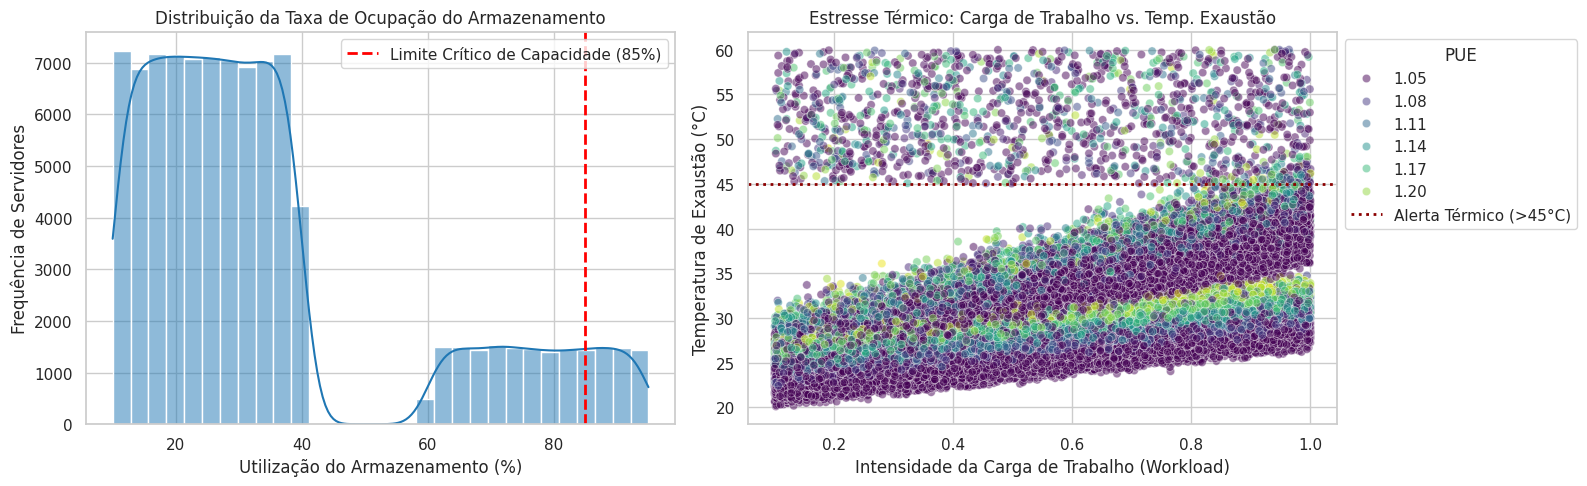


TESTE DE HIPÓTESE: CONSUMO ENERGÉTICO vs. CUSTO OPERACIONAL
• Coeficiente de Correlação de Pearson (r): 0.9125
• Coeficiente de Determinação (R²):         0.8327
• Custo Marginal por kW consumido (Beta):   $0.1811 USD/kW
• Custo Base Fixo Estimado (Alpha):         $-1.20 USD
• Valor-p (p-value):                          0.0000e+00
-----------------------------------------------------------------
PARECER ESTATÍSTICO: Rejeita-se H0 ao nível de significância de 5%.
O aumento do consumo elétrico acarreta elevação direta, linear e
estatisticamente significante dos custos operacionais do Data Center.



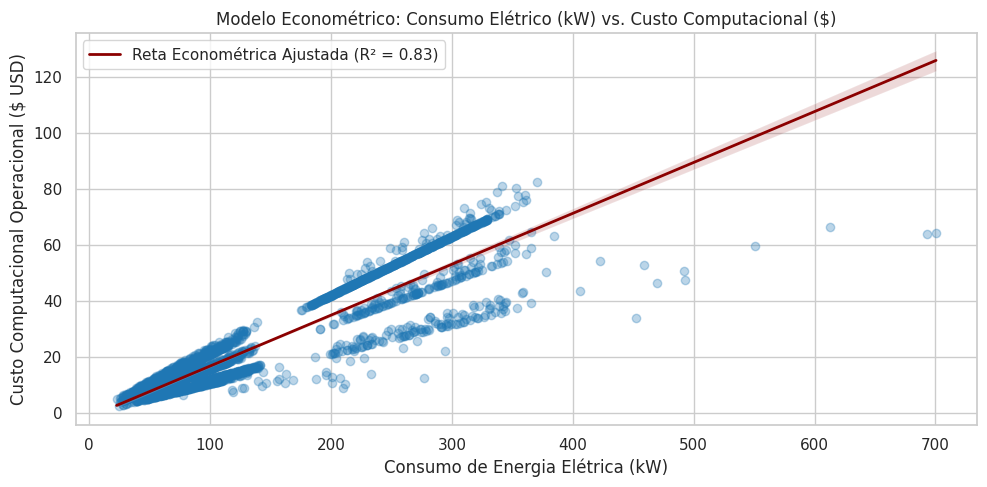

In [3]:
# Importação de módulos gráficos e estatísticos
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuração de estilo para gráficos executivos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (16, 5)
plt.rcParams["font.size"] = 11

# ==============================================================================
# 1. DIAGNÓSTICO VISUAL DE CAPACIDADE E RISCO TÉRMICO
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Parâmetros críticos de negócio
LIMITE_STORAGE_CRITICO = 85.0
LIMITE_TERMICO_CRITICO = 45.0

# Gráfico 1: Ocupação do Armazenamento (Histograma + KDE)
sns.histplot(
    data=df_clean,
    x="storage_utilization",
    kde=True,
    bins=30,
    color="#1f77b4",
    ax=axes[0]
)
axes[0].axvline(
    LIMITE_STORAGE_CRITICO,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Limite Crítico de Capacidade ({LIMITE_STORAGE_CRITICO:.0f}%)"
)
axes[0].set_title("Distribuição da Taxa de Ocupação do Armazenamento")
axes[0].set_xlabel("Utilização do Armazenamento (%)")
axes[0].set_ylabel("Frequência de Servidores")
axes[0].legend(loc="upper right")

# Gráfico 2: Estresse Térmico (Dispersão Carga vs. Temperatura com PUE)
sns.scatterplot(
    data=df_clean,
    x="workload_intensity",
    y="exhaust_temperature_c",
    hue="pue",
    palette="viridis",
    alpha=0.5,
    ax=axes[1]
)
axes[1].axhline(
    LIMITE_TERMICO_CRITICO,
    color="darkred",
    linestyle=":",
    linewidth=2,
    label=f"Alerta Térmico (>{LIMITE_TERMICO_CRITICO:.0f}°C)"
)
axes[1].set_title("Estresse Térmico: Carga de Trabalho vs. Temp. Exaustão")
axes[1].set_xlabel("Intensidade da Carga de Trabalho (Workload)")
axes[1].set_ylabel("Temperatura de Exaustão (°C)")
axes[1].legend(title="PUE", loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. MODELAGEM ECONOMÉTRICA (REGRESSÃO LINEAR SIMPLES)
# ==============================================================================
# Ajuste do modelo linear: Custo ($) = Alpha + Beta * Potência (kW)
coef_corr, p_valor = stats.pearsonr(df_clean["power_consumption_kw"], df_clean["compute_cost_usd"])
regressao = stats.linregress(df_clean["power_consumption_kw"], df_clean["compute_cost_usd"])

beta = regressao.slope
alpha = regressao.intercept
r_quadrado = regressao.rvalue ** 2

# Exibição dos resultados estatísticos formais
print("\n" + "=" * 65)
print("TESTE DE HIPÓTESE: CONSUMO ENERGÉTICO vs. CUSTO OPERACIONAL")
print("=" * 65)
print(f"• Coeficiente de Correlação de Pearson (r): {coef_corr:.4f}")
print(f"• Coeficiente de Determinação (R²):         {r_quadrado:.4f}")
print(f"• Custo Marginal por kW consumido (Beta):   ${beta:.4f} USD/kW")
print(f"• Custo Base Fixo Estimado (Alpha):         ${alpha:.2f} USD")
print(f"• Valor-p (p-value):                          {p_valor:.4e}")
print("-" * 65)

if p_valor < 0.05 and beta > 0:
    print("PARECER ESTATÍSTICO: Rejeita-se H0 ao nível de significância de 5%.")
    print("O aumento do consumo elétrico acarreta elevação direta, linear e")
    print("estatisticamente significante dos custos operacionais do Data Center.")
else:
    print("PARECER ESTATÍSTICO: Não há evidência estatística de relação linear positiva.")
print("=" * 65 + "\n")

# Gráfico de Regressão Econométrica
plt.figure(figsize=(10, 5))
sns.regplot(
    data=df_clean.sample(n=min(3000, len(df_clean)), random_state=42), # Amostragem para nitidez gráfica
    x="power_consumption_kw",
    y="compute_cost_usd",
    scatter_kws={"alpha": 0.3, "color": "#1f77b4"},
    line_kws={"color": "darkred", "linewidth": 2, "label": f"Reta Econométrica Ajustada (R² = {r_quadrado:.2f})"}
)
plt.title("Modelo Econométrico: Consumo Elétrico (kW) vs. Custo Computacional ($)")
plt.xlabel("Consumo de Energia Elétrica (kW)")
plt.ylabel("Custo Computacional Operacional ($ USD)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## **Fase 5: Compartilhar (Síntese Executiva dos Achados)**

Nesta etapa, consolidamos os resultados técnicos da Fase 4 em indicadores executivos claros (KPIs), facilitando a comunicação com a diretoria e partes interessadas (*stakeholders*).

**Resumo da Situação Operacional Atual:**
* **Capacidade de Armazenamento:** A ocupação média da infraestrutura é de **35,17%**, demonstrando uma folga volumétrica expressiva no nível global.
* **Faixa Crítica de Saturação:** Apenas **5,17%** dos nós operam na zona de alerta ($\ge 85\%$ de armazenamento).
* **Risco Térmico:** Apenas **1,59%** dos servidores atingiram o limiar crítico de estresse térmico ($\ge 45^\circ\text{C}$).
* **Eficiência Energética (PUE):** O índice PUE médio da frota é de **1,09**, o que indica um padrão de excelente eficiência energética operacional (muito próximo do limite ideal de $1,0$).
* **Relação Custo vs. Energia:** O modelo econométrico ($R^2 = 0{,}83$) confirma que $83\%$ do custo operacional de TI é explicado pelo consumo elétrico, apresentando um custo marginal de aproximadamente **$0,18 USD/kW**.

## **Fase 6: Agir (Matriz Prescritiva de Suporte à Decisão)**

A fase final do framework transforma o diagnóstico em uma recomendação prescritiva automatizada.

O algoritmo pondera as três dimensões da tríade de decisão:
1. **Risco:** Percentual de servidores em estado crítico de armazenamento ($\ge 85\%$).
2. **Custo:** Eficiência de carga e modelo econômico atual.
3. **Prazo (Lead Time):** Projeção da taxa de crescimento mensal da demanda de dados ($3{,}5\%$ ao mês) comparada à janela temporal necessária para construir/comissionar uma nova unidade (**6 meses**).

In [4]:
# ==============================================================================
# FASE 6: AGIR - ALGORITMO PRESCRITIVO E MATRIZ DE DECISÃO
# ==============================================================================

# 1. Parâmetros e Regras de Negócio do SSD
LIMIAR_STORAGE_CRITICO = 85.0     # Percentual de ocupação limite
LEAD_TIME_EXPANSAO_MESES = 6.0     # Prazo necessário para entregar novo prédio/módulo
TAXA_CRESCIMENTO_MENSAL_PCT = 3.5  # Projeção de crescimento mensal de armazenamento (%)

# 2. Consolidação das Métricas da Base Higienizada (df_clean)
utilizacao_media_storage = df_clean["storage_utilization"].mean()
prop_servidores_cheios = (df_clean["storage_utilization"] >= LIMIAR_STORAGE_CRITICO).mean() * 100
prop_estresse_termico = (df_clean["exhaust_temperature_c"] >= 45.0).mean() * 100
pue_medio = df_clean["pue"].mean()

# Projeção de Prazo: Tempo até o armazenamento médio atingir a marca crítica (85%)
margem_capacidade_restante = LIMIAR_STORAGE_CRITICO - utilizacao_media_storage
meses_ate_saturacao = margem_capacidade_restante / TAXA_CRESCIMENTO_MENSAL_PCT

# 3. Painel Executivo de Indicadores (KPIs)
print("=" * 70)
print("PAINEL EXECUTIVO SSD - INFRAESTRUTURA DE DATA CENTER (v2.0)")
print("=" * 70)
print(f"• Taxa Média de Ocupação do Armazenamento:   {utilizacao_media_storage:.2f}%")
print(f"• Servidores em Zona Crítica (>= 85%):        {prop_servidores_cheios:.2f}% dos nós")
print(f"• Servidores sob Estresse Térmico (>= 45°C):   {prop_estresse_termico:.2f}% dos nós")
print(f"• Índice Médio de Eficiência Energética (PUE): {pue_medio:.2f}")
print(f"• Projeção Temporal até a Saturação:          {meses_ate_saturacao:.1f} meses")
print(f"• Prazo de Implementação (Lead Time Expansão): {LEAD_TIME_EXPANSAO_MESES:.1f} meses")
print("-" * 70)

# 4. Motor de Regras Prescritivas de Suporte à Decisão
print("PARECER PRESCRITIVO FINAL DO SISTEMA DE SUPORTE À DECISÃO:")
print("-" * 70)

if meses_ate_saturacao <= LEAD_TIME_EXPANSAO_MESES or prop_servidores_cheios > 15.0:
    decisao_final = "APROVAR EXPANSÃO IMEDIATA DA NOVA UNIDADE"
    prioridade = "ALTA / CRÍTICA"
    justificativa = (
        f"O tempo projetado até o esgotamento ({meses_ate_saturacao:.1f} meses) é inferior ou "
        f"muito próximo ao lead time de expansão física ({LEAD_TIME_EXPANSAO_MESES:.1f} meses), "
        f"com risco elevado de ruptura de SLA."
    )
else:
    decisao_final = "POSTERGAR EXPANSÃO E OTIMIZAR RECURSOS ATUAIS"
    prioridade = "MODERADA / GERENCIAL"
    justificativa = (
        f"A infraestrutura atual possui folga de capacidade para suportar a operação por "
        f"{meses_ate_saturacao:.1f} meses — superando com folga o lead time de {LEAD_TIME_EXPANSAO_MESES:.1f} meses. "
        f"Recomenda-se evitar o desembolso prematuro de Capex e realizar o balanceamento "
        f"de carga nos {prop_servidores_cheios:.1f}% de nós em faixa alta."
    )

print(f"DECISÃO RECOMENDADA: [{decisao_final}]")
print(f"Grau de Prioridade:  {prioridade}")
print(f"Fundamentação:       {justificativa}")
print("=" * 70 + "\n")

PAINEL EXECUTIVO SSD - INFRAESTRUTURA DE DATA CENTER (v2.0)
• Taxa Média de Ocupação do Armazenamento:   35.17%
• Servidores em Zona Crítica (>= 85%):        5.55% dos nós
• Servidores sob Estresse Térmico (>= 45°C):   1.59% dos nós
• Índice Médio de Eficiência Energética (PUE): 1.09
• Projeção Temporal até a Saturação:          14.2 meses
• Prazo de Implementação (Lead Time Expansão): 6.0 meses
----------------------------------------------------------------------
PARECER PRESCRITIVO FINAL DO SISTEMA DE SUPORTE À DECISÃO:
----------------------------------------------------------------------
DECISÃO RECOMENDADA: [POSTERGAR EXPANSÃO E OTIMIZAR RECURSOS ATUAIS]
Grau de Prioridade:  MODERADA / GERENCIAL
Fundamentação:       A infraestrutura atual possui folga de capacidade para suportar a operação por 14.2 meses — superando com folga o lead time de 6.0 meses. Recomenda-se evitar o desembolso prematuro de Capex e realizar o balanceamento de carga nos 5.6% de nós em faixa alta.



### **Limitações da Modelagem e Riscos Macroeconômicos**

Embora o algoritmo prescritivo do SSD forneça um suporte quantitativo robusto baseado na telemetria interna, a tomada de decisão estratégica de *Capex* possui limitações que transcendem os limites da base de dados e exigem análise qualitativa:

* **Incerteza Geopolítica e Volatilidade Energética:** O modelo econométrico assume estabilidade no custo marginal da energia ($\beta \approx \$0{,}18\text{ USD/kW}$). No entanto, tensões geopolíticas globais, conflitos regionais e transições na matriz energética podem gerar choques de oferta e inflação tarifária imprevisíveis, alterando a viabilidade financeira do *Opex* no curto prazo.
* **Gargalos na Cadeia de Suprimentos (*Supply Chain*):** A premissa fixa do *Lead Time* de **6 meses** para a construção e comissionamento de novos data centers assume fluidez no fornecimento de semicondutores, transformadores e sistemas de arrefecimento. Crises logísticas ou escassez de componentes de hardware podem estender esse prazo para 12 a 18 meses, exigindo a antecipação do gatilho de expansão física.
* **Simplificação Determinística:** O modelo projeta a saturação com base em um crescimento linear constante ($3{,}5\%$ ao mês). Flutuações pontuais causadas pelo treinamento súbito de novos modelos de IA ou picos não lineares de tráfego podem antecipar a janela de risco térmico e de armazenamento.

## **Conclusão Geral**

Este estudo demonstrou a implementação de um **Sistema de Suporte à Decisão (SSD)** reprodutível e estruturado em 6 etapas para o planejamento de capacidade em data centers de hiperescala.

A auditoria e a higienização dos dados de telemetria permitiram isolar o comportamento operacional real de 93.066 servidores, eliminando o viés de ativos obsoletos e confirmando que **83% dos custos operacionais** estão diretamente vinculados ao consumo de energia elétrica ($R^2 = 0{,}83$).

A matriz prescritiva concluiu que, com uma ocupação média atual de **35,17%**, baixo estresse térmico (**1,59%**) e excelente eficiência energética (**PUE 1,09**), a organização possui uma margem de segurança temporal de **14,2 meses** até atingir o limite crítico de armazenamento. Como essa margem é consideravelmente superior ao *Lead Time* físico de expansão (6 meses), a recomendação executiva final é **postergar o investimento imediato em Capex**, otimizando a alocação de carga nos servidores existentes e preservando o capital da empresa diante de incertezas macroeconômicas globais.